In [1]:
# Importing relevant libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

Device: cpu


In [2]:
# Loading All Four Datasets
mitbih_train = pd.read_csv(r"C:\Users\user\Desktop\Data Folder\mitbih_train.csv", header=None)
mitbih_test = pd.read_csv(r"C:\Users\user\Desktop\Data Folder\mitbih_test.csv", header=None)
ptb_normal = pd.read_csv(r"C:\Users\user\Desktop\Data Folder\ptbdb_normal.csv", header=None)
ptb_abnormal = pd.read_csv(r"C:\Users\user\Desktop\Data Folder\ptbdb_abnormal.csv", header=None)

print("MIT-BIH Train shape:", mitbih_train.shape)
print("MIT-BIH Test shape:", mitbih_test.shape)
print("PTB Normal shape:", ptb_normal.shape)
print("PTB Abnormal shape:", ptb_abnormal.shape)

MIT-BIH Train shape: (87554, 188)
MIT-BIH Test shape: (21892, 188)
PTB Normal shape: (4046, 188)
PTB Abnormal shape: (10506, 188)


In [3]:
# Dataset Overview and Label Analysis
print("MIT-BIH Train last column (labels):", mitbih_train.iloc[:, -1].unique())
print("MIT-BIH Test last column (labels):", mitbih_test.iloc[:, -1].unique())
print("PTB files have binary labels in last column (0=normal, 1=abnormal)")

# Quick label distribution
print("\nMIT-BIH Train class distribution:\n", mitbih_train.iloc[:, -1].value_counts().sort_index())
print("MIT-BIH Test class distribution:\n", mitbih_test.iloc[:, -1].value_counts().sort_index())

MIT-BIH Train last column (labels): [0. 1. 2. 3. 4.]
MIT-BIH Test last column (labels): [0. 1. 2. 3. 4.]
PTB files have binary labels in last column (0=normal, 1=abnormal)

MIT-BIH Train class distribution:
 187
0.0    72471
1.0     2223
2.0     5788
3.0      641
4.0     6431
Name: count, dtype: int64
MIT-BIH Test class distribution:
 187
0.0    18118
1.0      556
2.0     1448
3.0      162
4.0     1608
Name: count, dtype: int64


Signal length MIT-BIH: 187
Signal length PTB: 187


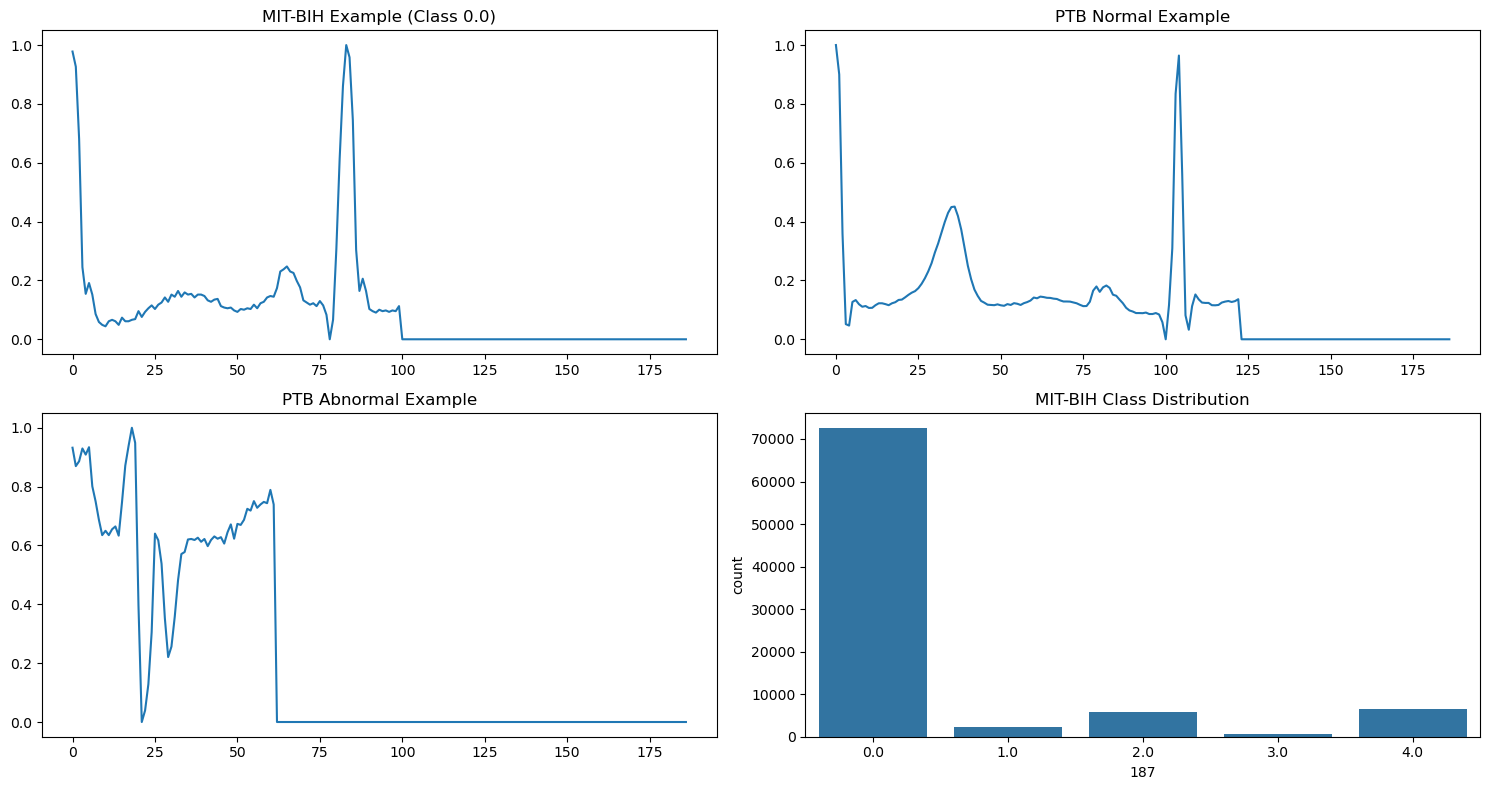

In [4]:
# Exploratory Data Analysis - Signal Lengths and Statistics
print("Signal length MIT-BIH:", mitbih_train.shape[1]-1)
print("Signal length PTB:", ptb_normal.shape[1]-1)

# Plot example signals
plt.figure(figsize=(15, 8))
plt.subplot(2, 2, 1)
plt.plot(mitbih_train.iloc[0, :-1])
plt.title('MIT-BIH Example (Class ' + str(mitbih_train.iloc[0, -1]) + ')')

plt.subplot(2, 2, 2)
plt.plot(ptb_normal.iloc[0, :-1])
plt.title('PTB Normal Example')

plt.subplot(2, 2, 3)
plt.plot(ptb_abnormal.iloc[0, :-1])
plt.title('PTB Abnormal Example')

plt.subplot(2, 2, 4)
sns.countplot(x=mitbih_train.iloc[:, -1])
plt.title('MIT-BIH Class Distribution')
plt.tight_layout()
plt.show()

In [5]:
# Data Preprocessing - Combining and Aligning Signals
# Step 1: Extract features and labels
X_mit_train = mitbih_train.iloc[:, :-1].values
y_mit_train = mitbih_train.iloc[:, -1].values.astype(int)

X_mit_test = mitbih_test.iloc[:, :-1].values
y_mit_test = mitbih_test.iloc[:, -1].values.astype(int)

X_ptb_normal = ptb_normal.iloc[:, :-1].values
y_ptb_normal = np.zeros(len(X_ptb_normal), dtype=int)

X_ptb_abnormal = ptb_abnormal.iloc[:, :-1].values
y_ptb_abnormal = np.ones(len(X_ptb_abnormal), dtype=int)

# Step 2: Find max length for padding
max_len = max(X_mit_train.shape[1], X_mit_test.shape[1], X_ptb_normal.shape[1], X_ptb_abnormal.shape[1])
print("Max signal length for padding:", max_len)

# Padding function
def pad_signals(X, max_len):
    padded = np.zeros((len(X), max_len))
    padded[:, :X.shape[1]] = X
    return padded

X_mit_train = pad_signals(X_mit_train, max_len)
X_mit_test = pad_signals(X_mit_test, max_len)
X_ptb_normal = pad_signals(X_ptb_normal, max_len)
X_ptb_abnormal = pad_signals(X_ptb_abnormal, max_len)

print("All signals padded to length:", max_len)

Max signal length for padding: 187
All signals padded to length: 187


In [6]:
# Creating Multi-Task Dataset with Domain Flag
# Combining all data
X = np.vstack([X_mit_train, X_mit_test, X_ptb_normal, X_ptb_abnormal])
y_arrhythmia = np.concatenate([y_mit_train, y_mit_test, np.zeros(len(X_ptb_normal)), np.zeros(len(X_ptb_abnormal))])  # MIT labels, PTB as class 0 (normal)
y_mi = np.concatenate([np.zeros(len(y_mit_train) + len(y_mit_test)), y_ptb_normal, y_ptb_abnormal])  # Binary MI task

domain = np.concatenate([
    np.zeros(len(y_mit_train) + len(y_mit_test)),   # 0 = MIT-BIH domain
    np.ones(len(X_ptb_normal) + len(X_ptb_abnormal)) # 1 = PTB domain
])

print("Combined dataset shape:", X.shape)
print("Arrhythmia classes:", np.unique(y_arrhythmia))
print("MI classes:", np.unique(y_mi))

Combined dataset shape: (123998, 187)
Arrhythmia classes: [0. 1. 2. 3. 4.]
MI classes: [0. 1.]


In [7]:
# Scaling and Final Reshape
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Reshape for 1D models: (samples, timesteps, 1)
X_final = X_scaled.reshape(X_scaled.shape[0], X_scaled.shape[1], 1)

print("Final data shape:", X_final.shape)

Final data shape: (123998, 187, 1)


In [8]:
# Train-Test Split for Multi-Task
from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(split.split(X_final, domain))

X_train, X_test = X_final[train_idx], X_final[test_idx]
y_arr_train, y_arr_test = y_arrhythmia[train_idx], y_arrhythmia[test_idx]
y_mi_train, y_mi_test = y_mi[train_idx], y_mi[test_idx]
domain_train, domain_test = domain[train_idx], domain[test_idx]

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Train size: 99198
Test size: 24800


In [9]:
# PyTorch Dataset and DataLoaders
class MultiTaskECGDataset(torch.utils.data.Dataset):
    def __init__(self, X, y_arr, y_mi):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y_arr = torch.tensor(y_arr, dtype=torch.long)
        self.y_mi = torch.tensor(y_mi, dtype=torch.long)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y_arr[idx], self.y_mi[idx]

train_dataset = MultiTaskECGDataset(X_train, y_arr_train, y_mi_train)
test_dataset = MultiTaskECGDataset(X_test, y_arr_test, y_mi_test)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [10]:
# Defining Multi-Task Model (Shared Backbone + Two Heads)
class MultiTaskECGModel(nn.Module):
    def __init__(self, seq_len=max_len, num_arr_classes=5):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Flatten()
        )
        
        # Calculate flattened size
        with torch.no_grad():
            dummy = torch.zeros(1, 1, seq_len)
            flat_size = self.backbone(dummy).shape[1]
        
        self.arr_head = nn.Sequential(
            nn.Linear(flat_size, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_arr_classes)
        )
        
        self.mi_head = nn.Sequential(
            nn.Linear(flat_size, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 2)
        )
    
    def forward(self, x):
        x = x.permute(0, 2, 1)  # (batch, channels, seq)
        features = self.backbone(x)
        arr_out = self.arr_head(features)
        mi_out = self.mi_head(features)
        return arr_out, mi_out

model = MultiTaskECGModel().to(device)
print(model)
print("Flattened feature size:", model.backbone(torch.zeros(1, 1, max_len).to(device)).shape[1])

MultiTaskECGModel(
  (backbone): Sequential(
    (0): Conv1d(1, 32, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Flatten(start_dim=1, end_dim=-1)
  )
  (arr_head): Sequential(
    (0): Linear(in_features=2944, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, in

In [12]:
# Loss Function and Optimizer
criterion_arr = nn.CrossEntropyLoss()
criterion_mi = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

In [13]:
# Multi-Task Training Loop
num_epochs = 50
best_val_loss = float('inf')
patience = 10
counter = 0

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for batch_X, batch_arr, batch_mi in train_loader:
        batch_X = batch_X.to(device)
        batch_arr = batch_arr.to(device)
        batch_mi = batch_mi.to(device)
        
        optimizer.zero_grad()
        arr_out, mi_out = model(batch_X)
        
        loss_arr = criterion_arr(arr_out, batch_arr)
        loss_mi = criterion_mi(mi_out, batch_mi)
        loss = 0.6 * loss_arr + 0.4 * loss_mi   # weighted multi-task loss
        
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    avg_loss = total_loss / len(train_loader)
    scheduler.step(avg_loss)
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] - Avg Loss: {avg_loss:.4f}")
    
    # Simple early stopping (can be expanded)
    if avg_loss < best_val_loss:
        best_val_loss = avg_loss
        counter = 0
        torch.save(model.state_dict(), 'best_multitask_ecg.pth')
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered!")
            break

Epoch [5/50] - Avg Loss: 0.0347
Epoch [10/50] - Avg Loss: 0.0204
Epoch [15/50] - Avg Loss: 0.0144
Epoch [20/50] - Avg Loss: 0.0122
Epoch [25/50] - Avg Loss: 0.0104
Epoch [30/50] - Avg Loss: 0.0096
Epoch [35/50] - Avg Loss: 0.0083
Epoch [40/50] - Avg Loss: 0.0084
Epoch [45/50] - Avg Loss: 0.0071
Epoch [50/50] - Avg Loss: 0.0076


In [14]:
# Evaluation on Test Set
model.load_state_dict(torch.load('best_multitask_ecg.pth'))
model.eval()

all_arr_pred, all_arr_true = [], []
all_mi_pred, all_mi_true = [], []
all_mi_prob = []

with torch.no_grad():
    for batch_X, batch_arr, batch_mi in test_loader:
        batch_X = batch_X.to(device)
        arr_out, mi_out = model(batch_X)
        
        arr_pred = arr_out.argmax(dim=1).cpu().numpy()
        mi_pred = mi_out.argmax(dim=1).cpu().numpy()
        mi_prob = torch.softmax(mi_out, dim=1)[:, 1].cpu().numpy()
        
        all_arr_pred.extend(arr_pred)
        all_arr_true.extend(batch_arr.cpu().numpy())
        all_mi_pred.extend(mi_pred)
        all_mi_true.extend(batch_mi.cpu().numpy())
        all_mi_prob.extend(mi_prob)

print("Arrhythmia Task (5-class)")
print(classification_report(all_arr_true, all_arr_pred, digits=4))

print("\n Myocardial Infarction Task (Binary)")
print(classification_report(all_mi_true, all_mi_pred, digits=4))
print("ROC-AUC (MI):", roc_auc_score(all_mi_true, all_mi_prob))

Arrhythmia Task (5-class)
              precision    recall  f1-score   support

           0     0.9935    0.9963    0.9949     20967
           1     0.8963    0.8582    0.8768       564
           2     0.9684    0.9664    0.9674      1427
           3     0.8769    0.7308    0.7972       156
           4     0.9952    0.9917    0.9935      1686

    accuracy                         0.9894     24800
   macro avg     0.9461    0.9087    0.9259     24800
weighted avg     0.9892    0.9894    0.9893     24800


 Myocardial Infarction Task (Binary)
              precision    recall  f1-score   support

           0     0.9977    0.9990    0.9983     22694
           1     0.9894    0.9748    0.9821      2106

    accuracy                         0.9970     24800
   macro avg     0.9935    0.9869    0.9902     24800
weighted avg     0.9970    0.9970    0.9970     24800

ROC-AUC (MI): 0.999723058945761


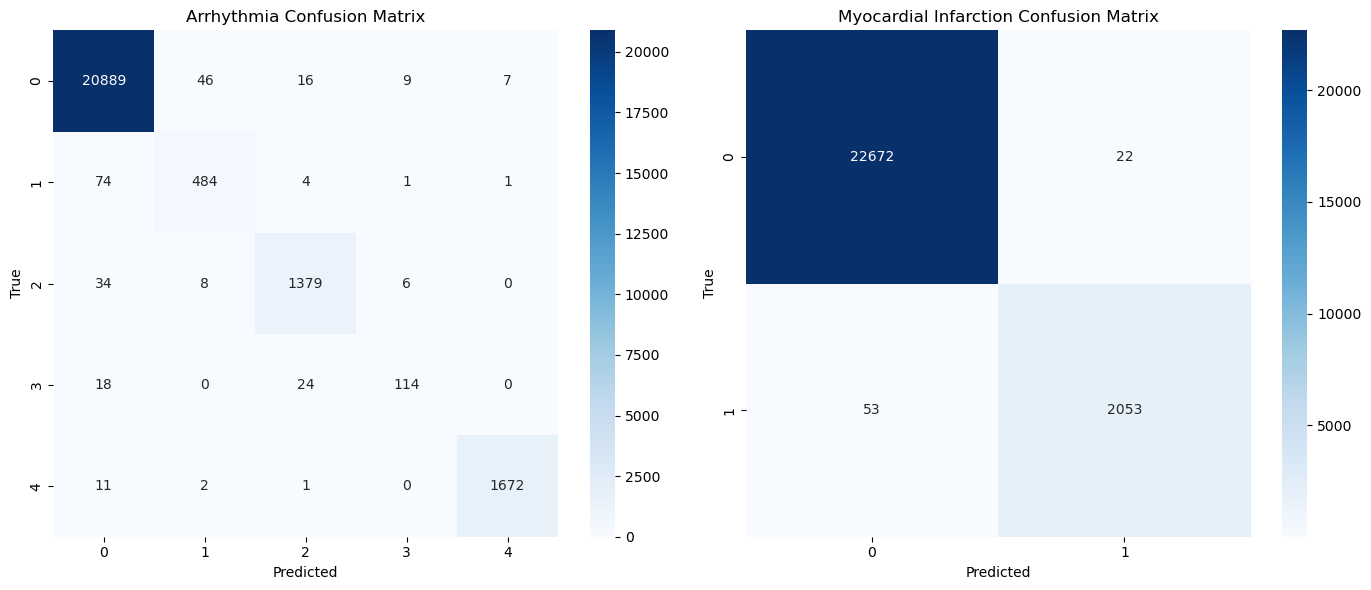

In [15]:
# Confusion Matrices and Visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(confusion_matrix(all_arr_true, all_arr_pred), annot=True, fmt='d', ax=axes[0], cmap='Blues')
axes[0].set_title('Arrhythmia Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

sns.heatmap(confusion_matrix(all_mi_true, all_mi_pred), annot=True, fmt='d', ax=axes[1], cmap='Blues')
axes[1].set_title('Myocardial Infarction Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.show()

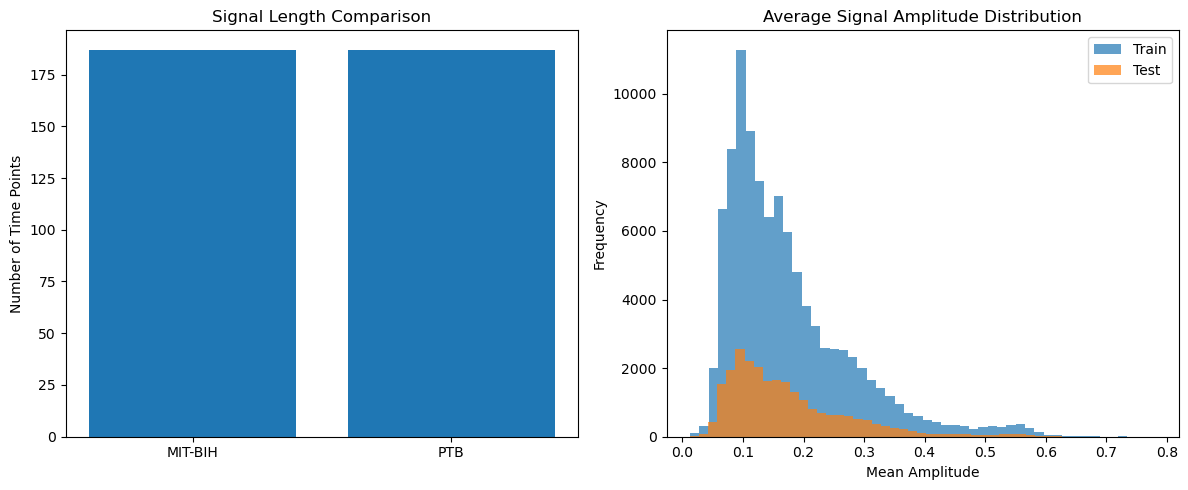

In [16]:
# Signal Length Distribution Across Datasets
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
lengths_mit = mitbih_train.shape[1] - 1
lengths_ptb = ptb_normal.shape[1] - 1
plt.bar(['MIT-BIH', 'PTB'], [lengths_mit, lengths_ptb])
plt.title('Signal Length Comparison')
plt.ylabel('Number of Time Points')

plt.subplot(1, 2, 2)
plt.hist(X_train.reshape(X_train.shape[0], -1).mean(axis=1), bins=50, alpha=0.7, label='Train')
plt.hist(X_test.reshape(X_test.shape[0], -1).mean(axis=1), bins=50, alpha=0.7, label='Test')
plt.title('Average Signal Amplitude Distribution')
plt.xlabel('Mean Amplitude')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

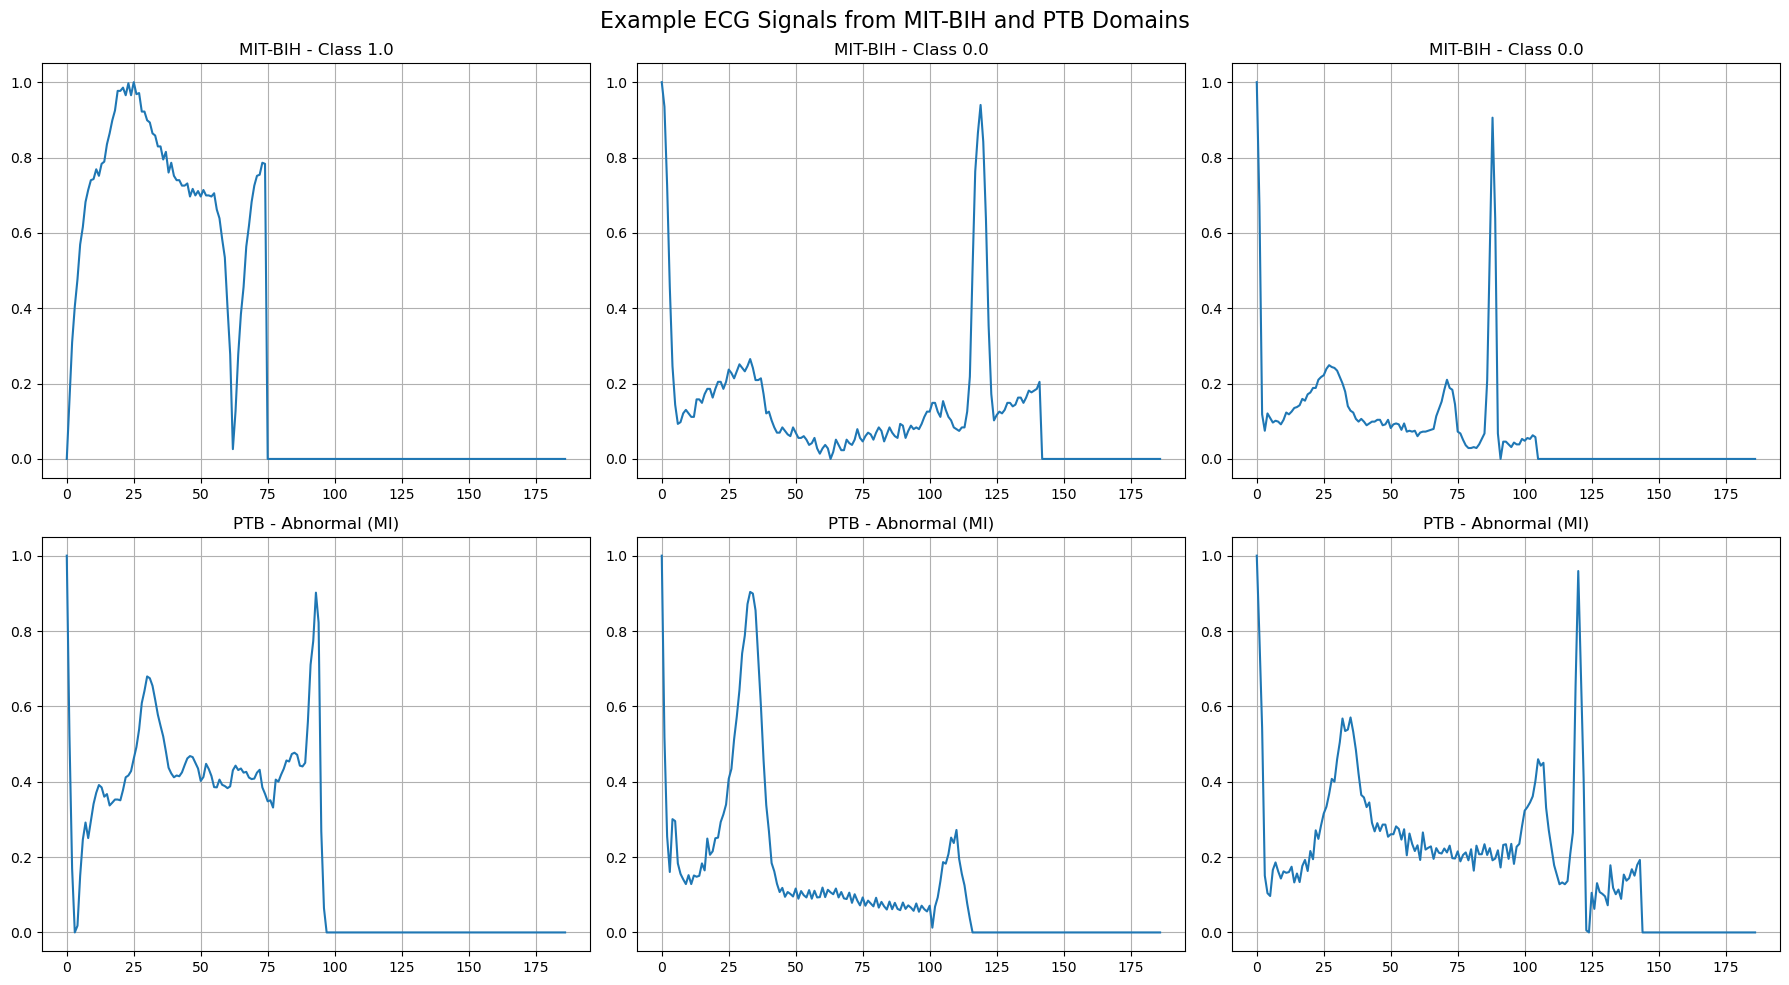

In [17]:
# Example of ECG Signals from Each Task/Domain
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# MIT-BIH examples
mit_idx = np.where(domain_train == 0)[0][:3]
for i, idx in enumerate(mit_idx[:3]):
    axes[0, i].plot(X_train[idx].squeeze())
    axes[0, i].set_title(f'MIT-BIH - Class {y_arr_train[idx]}')
    axes[0, i].grid(True)

# PTB examples
ptb_idx = np.where(domain_train == 1)[0][:3]
for i, idx in enumerate(ptb_idx[:3]):
    axes[1, i].plot(X_train[idx].squeeze())
    label = "Normal" if y_mi_train[idx] == 0 else "Abnormal (MI)"
    axes[1, i].set_title(f'PTB - {label}')
    axes[1, i].grid(True)

plt.suptitle('Example ECG Signals from MIT-BIH and PTB Domains', fontsize=16)
plt.tight_layout()
plt.show()

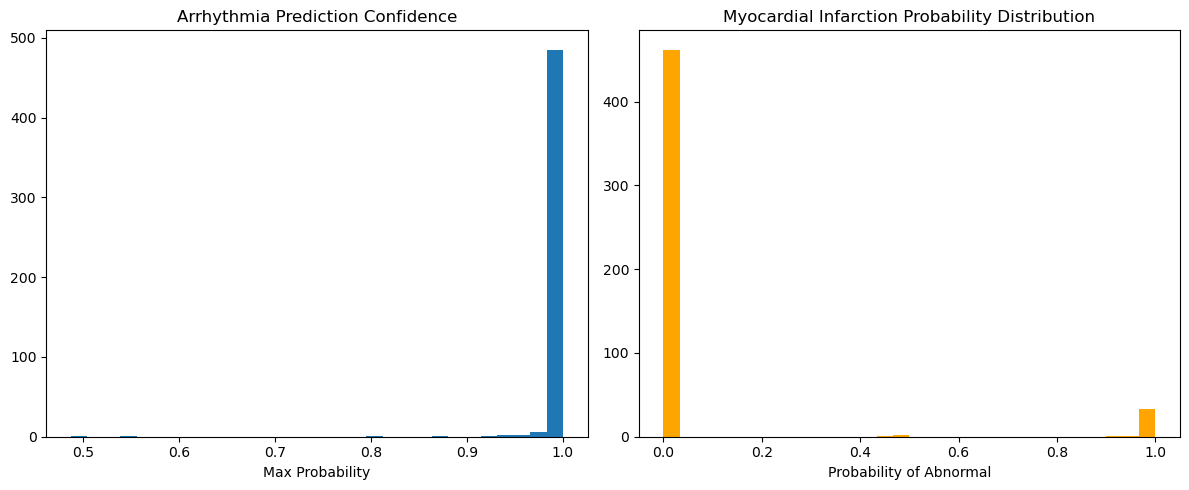

In [18]:
# Reconstruction Error Analysis 
# For multi-task, we plot prediction confidence instead
plt.figure(figsize=(12, 5))

# Arrhythmia task confidence
arr_probs = torch.softmax(model(torch.tensor(X_test[:500], dtype=torch.float32).to(device))[0], dim=1).max(dim=1)[0].cpu().detach().numpy()
plt.subplot(1, 2, 1)
plt.hist(arr_probs, bins=30)
plt.title('Arrhythmia Prediction Confidence')
plt.xlabel('Max Probability')

# MI task probability
mi_probs = torch.softmax(model(torch.tensor(X_test[:500], dtype=torch.float32).to(device))[1], dim=1)[:, 1].cpu().detach().numpy()
plt.subplot(1, 2, 2)
plt.hist(mi_probs, bins=30, color='orange')
plt.title('Myocardial Infarction Probability Distribution')
plt.xlabel('Probability of Abnormal')
plt.tight_layout()
plt.show()

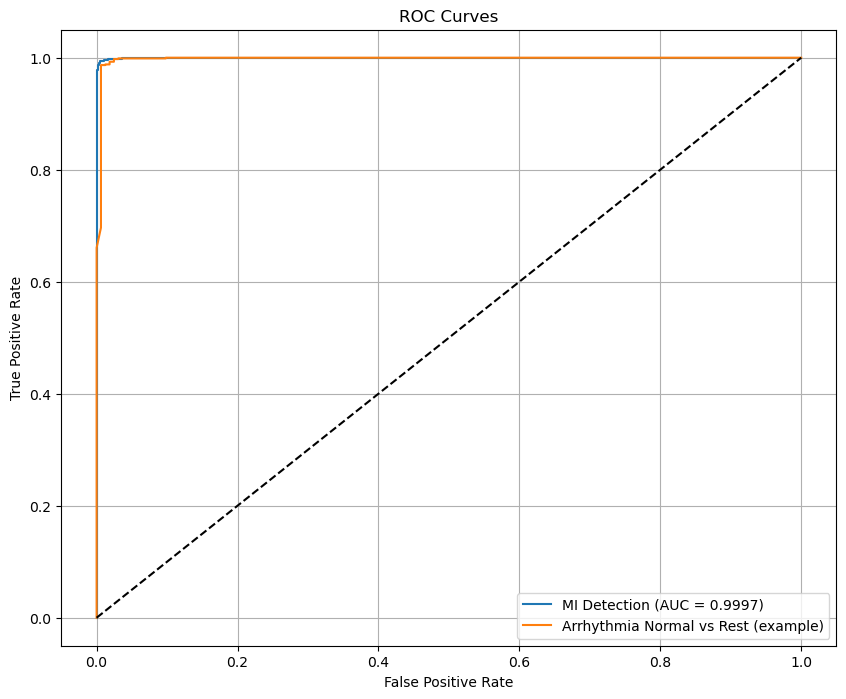

In [19]:
# ROC Curves for Both Tasks
from sklearn.metrics import roc_curve, auc

# For binary MI task
fpr_mi, tpr_mi, _ = roc_curve(all_mi_true, all_mi_prob)
roc_auc_mi = auc(fpr_mi, tpr_mi)

plt.figure(figsize=(10, 8))
plt.plot(fpr_mi, tpr_mi, label=f'MI Detection (AUC = {roc_auc_mi:.4f})')

# For arrhythmia, we can plot one-vs-rest for class 0 (Normal) as example
arr_probs_normal = torch.softmax(model(torch.tensor(X_test[:1000], dtype=torch.float32).to(device))[0], dim=1)[:, 0].cpu().detach().numpy()
fpr_arr, tpr_arr, _ = roc_curve((np.array(all_arr_true) == 0).astype(int)[:1000], arr_probs_normal[:1000])
plt.plot(fpr_arr, tpr_arr, label='Arrhythmia Normal vs Rest (example)')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.grid(True)
plt.show()

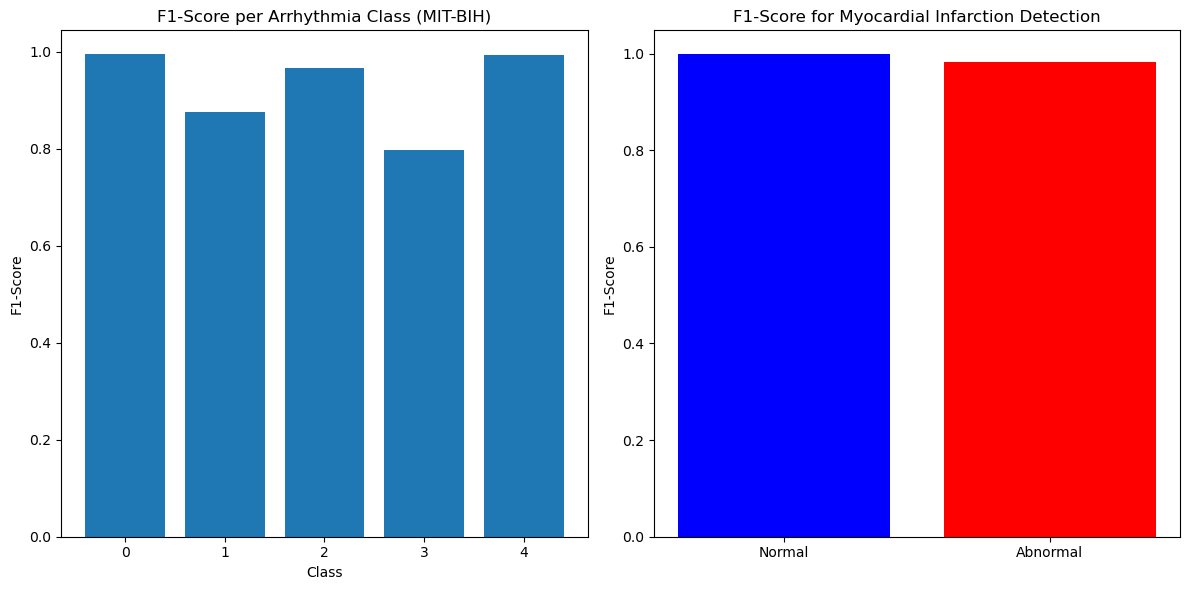

In [20]:
# Class-wise Performance Comparison
arr_report = classification_report(all_arr_true, all_arr_pred, output_dict=True)
mi_report = classification_report(all_mi_true, all_mi_pred, output_dict=True)

plt.figure(figsize=(12, 6))
metrics = ['precision', 'recall', 'f1-score']

# Arrhythmia classes
arr_f1 = [arr_report[str(i)]['f1-score'] for i in range(5)]
plt.subplot(1, 2, 1)
plt.bar(range(5), arr_f1)
plt.title('F1-Score per Arrhythmia Class (MIT-BIH)')
plt.xlabel('Class')
plt.ylabel('F1-Score')
plt.xticks(range(5))

# MI binary
plt.subplot(1, 2, 2)
mi_f1 = [mi_report['0']['f1-score'], mi_report['1']['f1-score']]
plt.bar(['Normal', 'Abnormal'], mi_f1, color=['blue', 'red'])
plt.title('F1-Score for Myocardial Infarction Detection')
plt.ylabel('F1-Score')
plt.tight_layout()
plt.show()

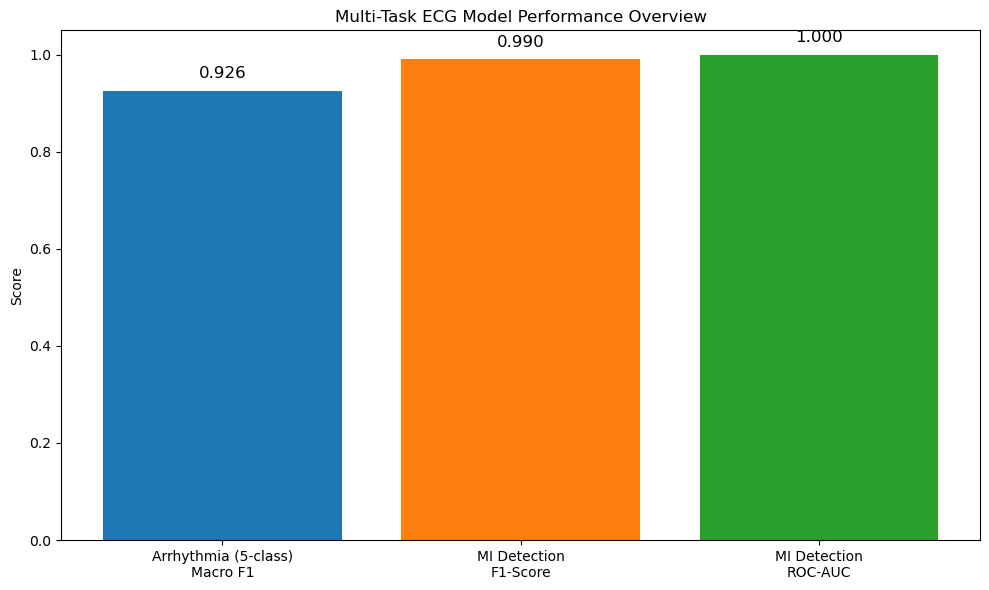

successfully completed.


In [21]:
#Performance Overview
fig, ax = plt.subplots(figsize=(10, 6))
tasks = ['Arrhythmia (5-class)\nMacro F1', 'MI Detection\nF1-Score', 'MI Detection\nROC-AUC']
scores = [
    classification_report(all_arr_true, all_arr_pred, output_dict=True)['macro avg']['f1-score'],
    classification_report(all_mi_true, all_mi_pred, output_dict=True)['macro avg']['f1-score'],
    roc_auc_score(all_mi_true, all_mi_prob)
]

bars = ax.bar(tasks, scores, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
ax.set_ylabel('Score')
ax.set_title('Multi-Task ECG Model Performance Overview')
ax.set_ylim(0, 1.05)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{height:.3f}', ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.show()

print("successfully completed.")